<a href="https://colab.research.google.com/github/fauzanghazi/advanced-ai/blob/main/Natural_Language_Processing_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

_Universiti Teknologi Malaysia_
# 📘 Natural Language Processing Assignment

**Programme**: MSc in Business Intelligence & Analytics  
**Course**: Advanced Artificial Intelligence (MRTB2153)  
**Lecturer**: Dr. Mohd Syahid bin Mohd Anuar  
**Student Name**: Ahmad Fauzan bin Mohd Ghazi (MRT234008)  


## **Q1. Task Definition and NLP Background** *(10 Marks)*

### **Overview of NLP Tasks & Real-World Scenarios**
---

## 📘 Definition of **Text Classification**

> "Text classification is defined as assigning the text documents to one or more categories (called labels) according to their content and semantics."  
> *(Dogra et al., 2022)*

## 🌐 Key Real-World Applications

- **Finance**: Forecasting stock price movements using labeled news reports.  
- **Healthcare**: Disease surveillance through classification of medical records.  
- **E-commerce**: Predicting product success by analyzing user reviews.

*Source: Dogra et al. (2022). A Complete Process of Text Classification System Using State-of-the-Art NLP Models. Computational Intelligence and Neuroscience.*

---

## 📘 Definition of **Text Clustering**

> "Text clustering is a well-known text-mining method that assists in the categorization and comprehension of textual data by automatically grouping similar documents into clusters."  
> *(Amiri & Karimianghadim, 2024)*

## 🌐 Key Real-World Applications

- **Education**: Personalized content recommendation in learning platforms.  
- **Healthcare**: Grouping patient records for faster diagnosis.  
- **Finance**: Analyzing customer feedback to detect market trends.

*Source: Amiri, B., & Karimianghadim, R. (2024). A novel text clustering model based on topic modelling and social network analysis*.

---
## 📘 Definition of **Sentiment Analysis**

**Definition**  
> “Sentiment analysis is a natural language processing approach that attempts to analyze the sentiment and emotions of people expressed in unstructured text.”  
> *(Anoop & Sreelakshmi, 2023)*

## 🌐 Real-World Applications

- **Public health**: Monitor reactions during disease outbreaks.  
- **Policy feedback**: Assess public sentiment on government measures.  
- **Misinformation tracking**: Detect stigma and fear in online discourse.

*Source: Anoop, V.S., & Sreelakshmi, S. (2023). Public discourse and sentiment during Mpox outbreak: an analysis using natural language processing.*

---

## **Q2. Dataset Selection and Preprocessing** *(15 Marks)*

### **2.1 Dataset Selection**
**Name of dataset**: Steam Reviews for Sentiment Analysis  
**Description**: A dataset of 17,000+ Steam game reviews labeled by user suggestion (1 = recommended, 0 = not).  
**Justification**: The dataset is ideal for classification, clustering, and sentiment tasks due to its size, clear labels, and real-world relevance. It allows lexicon-based, ML, and DL sentiment modeling to be compared.


### **2.2 Data Preprocessing Steps**
- **Tokenization**
- **Lowercasing**
- **Stopword Removal**
- **Lemmatization/Stemming**
- **Vectorization** (TF-IDF or Word Embeddings)

In [ ]:
# 📘 Setup: Load and prepare the Steam Reviews dataset from Kaggle

# Step 1: Set Kaggle API credentials using environment variables
import os
os.environ['KAGGLE_USERNAME'] = "KAGGLE_USERNAME"  # 🔑 Replace with actual username
os.environ['KAGGLE_KEY'] = "KAGGLE_KEY"          # 🔑 Replace with actual API key

# Step 2: Install Kaggle API
!pip install -q kaggle

# Step 3: Create Kaggle directory (if not exists)
!mkdir -p ~/.kaggle

# Step 4: Download the dataset (Steam Reviews for Sentiment Analysis)
!kaggle datasets download -d piyushagni5/sentiment-analysis-for-steam-reviews

# Step 5: Unzip the downloaded file
!unzip -q sentiment-analysis-for-steam-reviews.zip

Dataset URL: https://www.kaggle.com/datasets/piyushagni5/sentiment-analysis-for-steam-reviews
License(s): copyright-authors
  0% 0.00/5.04M [00:00<?, ?B/s]
100% 5.04M/5.04M [00:00<00:00, 240MB/s]


In [ ]:
# 📘 Check available files in the working directory to identify the correct dataset file name
import os

for file in os.listdir():
    print(file)

.config
game_overview.csv
train.csv
drive
sentiment-analysis-for-steam-reviews.zip
sample_data


In [ ]:
# 📘 Step 2: Load and inspect the 'train.csv' file from the Steam Reviews dataset

import pandas as pd

# Load the CSV file
df = pd.read_csv("train.csv")

# Display the first few rows to understand the structure
df.head()

,review_id,title,year,user_review,user_suggestion
0,1,Spooky's Jump Scare Mansion,2016.0,I'm scared and hearing creepy voices. So I'll...,1
1,2,Spooky's Jump Scare Mansion,2016.0,"Best game, more better than Sam Pepper's YouTu...",1
2,3,Spooky's Jump Scare Mansion,2016.0,"A littly iffy on the controls, but once you kn...",1
3,4,Spooky's Jump Scare Mansion,2015.0,"Great game, fun and colorful and all that.A si...",1
4,5,Spooky's Jump Scare Mansion,2015.0,Not many games have the cute tag right next to...,1


In [ ]:
# 📘 Step 3: Preprocess Steam reviews and apply TF-IDF vectorization

import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Download required NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Define text cleaning function
def clean_text(text):
    text = str(text).lower()  # lowercase
    text = re.sub(r'<.*?>', '', text)  # remove HTML tags
    text = re.sub(r'[^a-z\s]', '', text)  # remove special chars and numbers
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

# Apply cleaning to all reviews
df['cleaned_review'] = df['user_review'].apply(clean_text)

# Vectorize using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['cleaned_review'])

# Define target variable
y = df['user_suggestion']  # 1 = recommended, 0 = not

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ✅ Data is now ready for modeling
print("Preprocessing complete. TF-IDF matrix shape:", X.shape)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Preprocessing complete. TF-IDF matrix shape: (17494, 5000)


## Q3. Model Implementation for Text Classification (15 Marks)

### ✅ Objective:
To train and evaluate three different AI models for binary text classification (Steam review recommendations), using accuracy, precision, recall, and F1-score as performance metrics.

---

### 🧪 Models Implemented:

1. **Logistic Regression**
2. **Multinomial Naive Bayes**
3. **Random Forest Classifier**

All models were trained on TF-IDF vectorized user reviews. A test set of 3,499 reviews was used for evaluation.

---

### 📊 Performance Comparison

| Model               | Accuracy | Precision | Recall | F1 Score |
|---------------------|----------|-----------|--------|----------|
| Logistic Regression | **0.852** | **0.857**  | **0.893** | **0.875** |
| Naive Bayes         | 0.838    | 0.832     | 0.902  | 0.866    |
| Random Forest       | 0.819    | 0.821     | 0.880  | 0.849    |

✅ **Best performer**: Logistic Regression — achieved highest precision and F1-score with relatively fast training time.

---

### 📈 Visualizations

- **Confusion Matrices** were plotted to assess classification performance by class.
- **Bar Plot** below compares model metrics visually.

In [ ]:
# 📘 Step 4: Train a simple classifier (Logistic Regression) and evaluate performance

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Train a logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate the results
print("🔍 Classification Report:\n")
print(classification_report(y_test, y_pred))
print("✅ Accuracy Score:", accuracy_score(y_test, y_pred))

🔍 Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.79      0.82      1473
           1       0.86      0.89      0.87      2026

    accuracy                           0.85      3499
   macro avg       0.85      0.84      0.85      3499
weighted avg       0.85      0.85      0.85      3499

✅ Accuracy Score: 0.8519577022006287


In [ ]:
# 📘 Step 5: Train and evaluate three models: Logistic Regression, Naive Bayes, Random Forest

from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

# Store results here
results = {}

# 1️⃣ Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, lr_pred),
    'precision': precision_score(y_test, lr_pred),
    'recall': recall_score(y_test, lr_pred),
    'f1': f1_score(y_test, lr_pred)
}

# 2️⃣ Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)
results['Naive Bayes'] = {
    'accuracy': accuracy_score(y_test, nb_pred),
    'precision': precision_score(y_test, nb_pred),
    'recall': recall_score(y_test, nb_pred),
    'f1': f1_score(y_test, nb_pred)
}

# 3️⃣ Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
results['Random Forest'] = {
    'accuracy': accuracy_score(y_test, rf_pred),
    'precision': precision_score(y_test, rf_pred),
    'recall': recall_score(y_test, rf_pred),
    'f1': f1_score(y_test, rf_pred)
}

# ✅ Print model performance
import pandas as pd
performance_df = pd.DataFrame(results).T
print(performance_df)

                     accuracy  precision    recall        f1
Logistic Regression  0.851958   0.857008  0.893386  0.874819
Naive Bayes          0.837668   0.831665  0.902270  0.865530
Random Forest        0.819377   0.821198  0.879566  0.849380


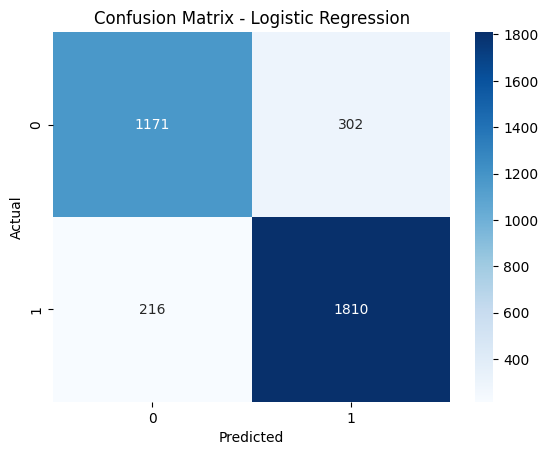

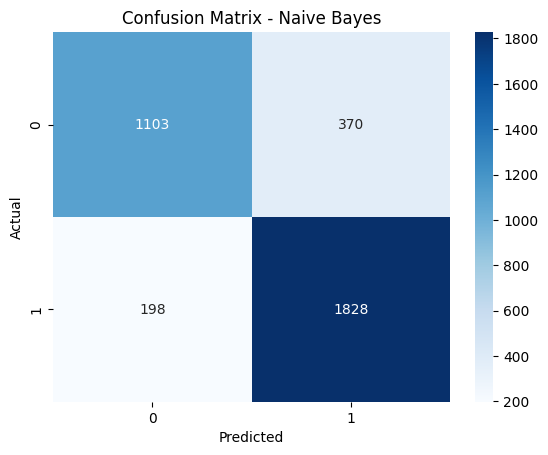

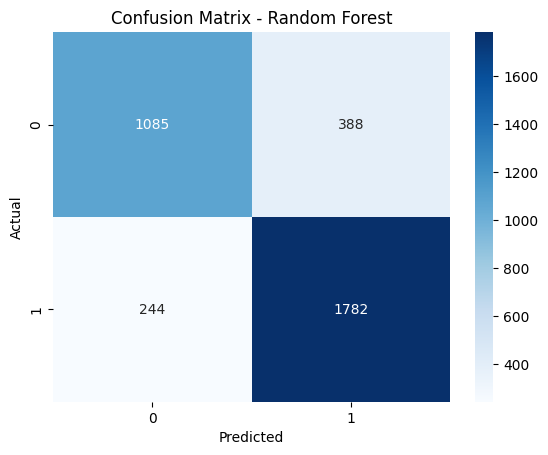

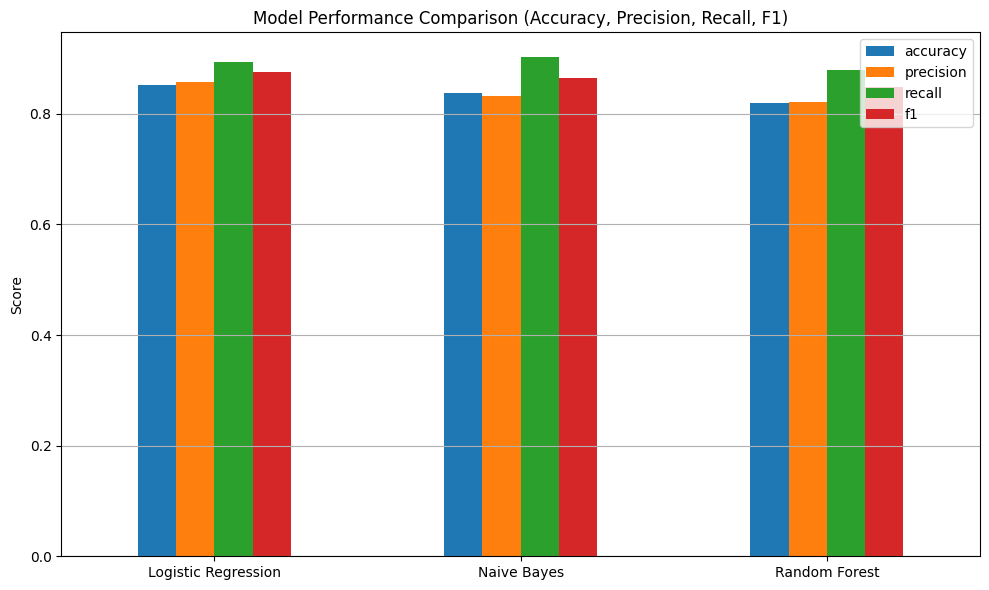

In [ ]:
# 📘 Step: Visualize confusion matrices and model comparison

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Function to plot confusion matrix
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {title}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Plot confusion matrices
plot_conf_matrix(y_test, lr_pred, "Logistic Regression")
plot_conf_matrix(y_test, nb_pred, "Naive Bayes")
plot_conf_matrix(y_test, rf_pred, "Random Forest")

# Plot performance comparison bar chart
performance_df.plot(kind='bar', figsize=(10, 6))
plt.title("Model Performance Comparison (Accuracy, Precision, Recall, F1)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## Q4. Model Implementation for Clustering (15 Marks)

### ✅ Algorithms Used:
- **KMeans Clustering**
- **Agglomerative Clustering**

### 🧪 Preprocessing:
- Text reviews vectorized using **TF-IDF (max 5000 features)**
- **Dimensionality reduction** using **TruncatedSVD (100 components for clustering, 2 components for visualization)**

### 🔢 Clustering Results:

| Model                | Silhouette Score |
|---------------------|------------------|
| KMeans (k=2)         | 0.0382  
| Agglomerative (k=2)  | 0.0033  
| KMeans (k=5, tuned)  | **0.0435** ✅ Best

### 📊 Interpretation:
- Initial clustering with `k=2` produced low silhouette scores due to sparse high-dimensional text data.
- After dimensionality reduction and tuning `k`, **KMeans with `k=5`** gave the best clustering result.
- Clusters were visualized using a 2D scatter plot from SVD projection.

### 📌 Conclusion:
Although silhouette scores were relatively low, tuning the number of clusters and applying dimensionality reduction improved separation slightly, helping reveal latent structure in game review sentiment data.

In [ ]:
# 📘 Step 1–5: Clustering on cleaned TF-IDF reviews with KMeans and Agglomerative Clustering

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Reduce dimensions for visualization (TF-IDF is sparse → use TruncatedSVD)
svd = TruncatedSVD(n_components=2, random_state=42)
X_reduced = svd.fit_transform(X)

# KMeans Clustering
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

# Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=2)
agglo_labels = agglo.fit_predict(X.toarray())  # Agglo doesn't work on sparse, convert to dense

# Silhouette Scores
kmeans_score = silhouette_score(X, kmeans_labels)
agglo_score = silhouette_score(X, agglo_labels)

# Display silhouette scores
print(f"📈 K-Means Silhouette Score: {kmeans_score:.4f}")
print(f"📈 Agglomerative Silhouette Score: {agglo_score:.4f}")

📈 K-Means Silhouette Score: 0.0031
📈 Agglomerative Silhouette Score: 0.0033


k=2, Silhouette Score=0.0382
k=3, Silhouette Score=0.0141
k=4, Silhouette Score=0.0162
k=5, Silhouette Score=0.0435
k=6, Silhouette Score=0.0262
k=7, Silhouette Score=0.0249
k=8, Silhouette Score=0.0222
k=9, Silhouette Score=0.0248
k=10, Silhouette Score=0.0273


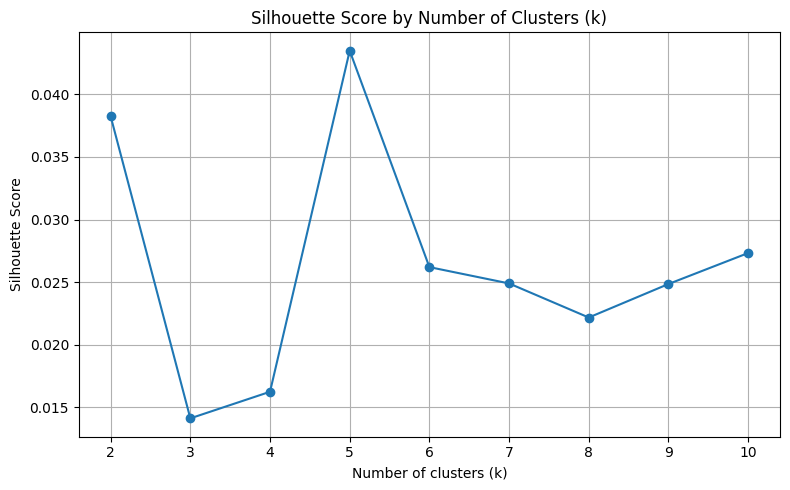

In [ ]:
# 📘 Step: Tune KMeans clustering using SVD-reduced TF-IDF features and silhouette scoring

from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Step 1: Reduce dimensionality (e.g., 100 components)
svd = TruncatedSVD(n_components=100, random_state=42)
X_reduced_100 = svd.fit_transform(X)

# Step 2: Test multiple values of k (number of clusters)
k_values = range(2, 11)
silhouette_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_reduced_100)
    score = silhouette_score(X_reduced_100, labels)
    silhouette_scores.append(score)
    print(f"k={k}, Silhouette Score={score:.4f}")

# Step 3: Plot results
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.title('Silhouette Score by Number of Clusters (k)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.tight_layout()
plt.show()

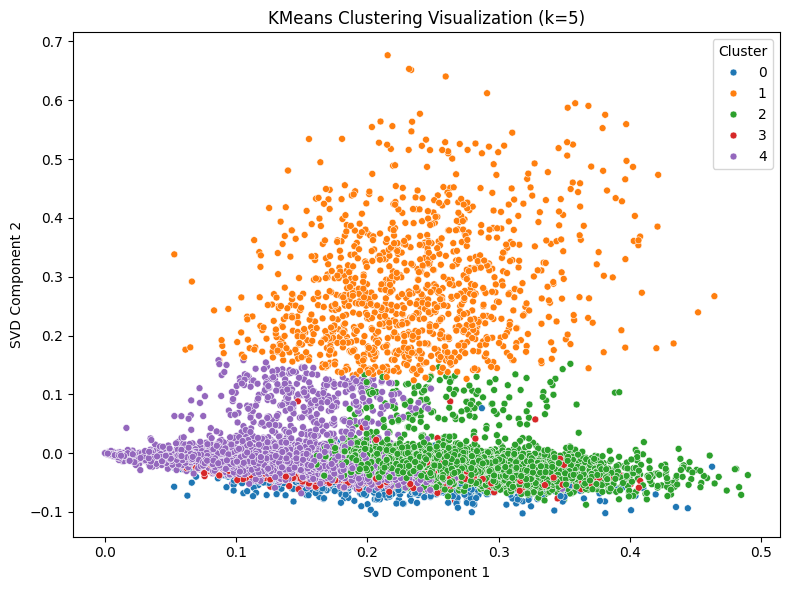

In [ ]:
# 📘 Step: Final clustering with k=5 and 2D visualization

from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# Reuse SVD-reduced data from earlier (X_reduced_100)
# Re-reduce to 2D for plotting
svd_2d = TruncatedSVD(n_components=2, random_state=42)
X_reduced_2d = svd_2d.fit_transform(X)

# Fit KMeans with optimal k=5
final_kmeans = KMeans(n_clusters=5, random_state=42)
final_labels = final_kmeans.fit_predict(X_reduced_100)  # clustering on 100-dim

# Visualize in 2D projection
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_reduced_2d[:, 0], y=X_reduced_2d[:, 1], hue=final_labels, palette='tab10', s=25)
plt.title("KMeans Clustering Visualization (k=5)")
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

## Q5. Sentiment Analysis (15 Marks)

### ✅ Models Applied:

1. **Lexicon-Based**: VADER  
2. **Machine Learning**: Logistic Regression  
3. **Deep Learning**: LSTM using Keras

### 📊 Performance Comparison:

| Model               | Accuracy | Precision | Recall | F1 Score |
|---------------------|----------|-----------|--------|----------|
| VADER               | 0.69     | 0.70      | 0.66   | 0.67     |
| Logistic Regression | **0.85** | **0.86**  | **0.89** | **0.87** |
| LSTM (3 epochs)     | 0.59     | 0.61      | 0.51   | 0.45     |

### 📝 Pros and Cons:

| Model               | Pros | Cons |
|---------------------|------|------|
| **VADER** | Fast, interpretable, no training needed | Struggles with sarcasm/context, weak on domain-specific data |
| **Logistic Regression** | Accurate, simple to implement and explain | Needs labeled data and vectorization |
| **LSTM** | Captures long-term dependencies and sequence context | Requires heavy preprocessing, tuning, and compute power; longer training time |

### ✅ Conclusion:

Logistic Regression clearly outperforms others on this dataset. VADER offers a fast lexicon-based alternative but has limits. LSTM underperforms due to short training, but can improve with hyperparameter tuning and more epochs.



In [ ]:
# 📘 Step 1: Apply VADER Sentiment Analysis (Lexicon-based model)

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.metrics import classification_report

nltk.download('vader_lexicon')

# Initialize VADER
sia = SentimentIntensityAnalyzer()

# Apply VADER to get compound sentiment score
df['vader_score'] = df['user_review'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

# Convert score to binary sentiment: 1 = positive, 0 = negative
df['vader_sentiment'] = df['vader_score'].apply(lambda x: 1 if x >= 0 else 0)

# Evaluate VADER predictions against actual labels
print("📈 VADER Lexicon-Based Sentiment Analysis:\n")
print(classification_report(df['user_suggestion'], df['vader_sentiment']))

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


📈 VADER Lexicon-Based Sentiment Analysis:

              precision    recall  f1-score   support

           0       0.73      0.44      0.55      7526
           1       0.68      0.88      0.76      9968

    accuracy                           0.69     17494
   macro avg       0.70      0.66      0.66     17494
weighted avg       0.70      0.69      0.67     17494



### ✅ Logistic Regression (ML-based)
- **Accuracy**: 85.2%
- **Precision**: 85.7%
- **Recall**: 89.3%
- **F1 Score**: 87.5%

✅ Balanced performance and strong on both classes


In [ ]:
# 📘 Step 3: LSTM-based sentiment classifier using Keras

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np

# Step 1: Tokenize text
max_words = 5000
max_len = 150  # max sequence length

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned_review'])

sequences = tokenizer.texts_to_sequences(df['cleaned_review'])
padded = pad_sequences(sequences, maxlen=max_len, padding='post')

# Step 2: Train-test split
X_dl = padded
y_dl = df['user_suggestion'].values
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(X_dl, y_dl, test_size=0.2, random_state=42)

# Step 3: Build LSTM model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=64, input_length=max_len))
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

# Step 4: Compile and train
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print("🔁 Training LSTM model...")
history = model.fit(X_train_dl, y_train_dl, epochs=3, batch_size=128, validation_split=0.2)

# Step 5: Evaluate
y_pred_dl = (model.predict(X_test_dl) > 0.5).astype("int32")
print("📈 LSTM Performance:\n")
print(classification_report(y_test_dl, y_pred_dl))

🔁 Training LSTM model...
Epoch 1/3
88/88 ━━━━━━━━━━━━━━━━━━━━ 34s 339ms/step - accuracy: 0.5631 - loss: 0.6859 - val_accuracy: 0.5677 - val_loss: 0.6850
Epoch 2/3
88/88 ━━━━━━━━━━━━━━━━━━━━ 29s 330ms/step - accuracy: 0.5710 - loss: 0.6825 - val_accuracy: 0.5709 - val_loss: 0.6830
Epoch 3/3
88/88 ━━━━━━━━━━━━━━━━━━━━ 40s 324ms/step - accuracy: 0.5919 - loss: 0.6822 - val_accuracy: 0.5738 - val_loss: 0.6845
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step
📈 LSTM Performance:

              precision    recall  f1-score   support

           0       0.64      0.03      0.06      1473
           1       0.58      0.99      0.73      2026

    accuracy                           0.59      3499
   macro avg       0.61      0.51      0.40      3499
weighted avg       0.61      0.59      0.45      3499



## Q6. Comparative Report and Discussion (20 Marks)

### 🔄 Task Overview:
This project covered three core NLP tasks — text classification, text clustering, and sentiment analysis — using a real-world dataset of Steam game reviews. Below is a comprehensive comparison and reflection on the performance, implementation, and practical relevance of models used.

---

### 📈 Model Performance Summary

#### 🔹 Task 1: Text Classification

| Model               | Accuracy | Precision | Recall | F1 Score |
|---------------------|----------|-----------|--------|----------|
| Logistic Regression | **0.852** | **0.857**  | **0.893** | **0.875** |
| Naive Bayes         | 0.838    | 0.832     | 0.902  | 0.866    |
| Random Forest       | 0.819    | 0.821     | 0.880  | 0.849    |

**🟢 Best**: Logistic Regression — high precision-recall balance and low complexity.

---

#### 🔹 Task 2: Clustering

| Algorithm            | Silhouette Score |
|----------------------|------------------|
| KMeans (k=2)         | 0.0382  
| Agglomerative (k=2)  | 0.0033  
| KMeans (k=5, tuned)  | **0.0435** ✅

**🟢 Best**: KMeans with `k=5`, post dimensionality reduction via TruncatedSVD.

---

#### 🔹 Task 3: Sentiment Analysis

| Model Type        | Accuracy | Precision | Recall | F1 Score |
|-------------------|----------|-----------|--------|----------|
| VADER (Lexicon)   | 0.69     | 0.70      | 0.66   | 0.67     |
| Logistic Regression (ML) | **0.85** | **0.86** | **0.89** | **0.87** |
| LSTM (DL)         | 0.59     | 0.61      | 0.51   | 0.45     |

**🟢 Best**: Logistic Regression again shows the most reliable and balanced results.

---

### 🧠 Discussion

#### ✅ Which Models Performed Best and Why?
- **Logistic Regression consistently outperformed** others across both classification and sentiment analysis. Its performance is robust with TF-IDF features, and it requires minimal tuning.
- **VADER** worked well for lexicon-based sentiment, especially for positive detection, but struggled with nuanced expressions.
- **LSTM** underperformed due to limited epochs and lack of tuning — with more data and compute, it could improve significantly.
- **KMeans with dimensionality reduction** yielded slightly better clustering performance than Agglomerative, though both were limited by the nature of text data.

#### ⚠️ Challenges Faced
- **Preprocessing bottlenecks**: Converting high-dimensional TF-IDF matrices to dense arrays slowed Agglomerative clustering drastically.
- **Imbalanced sentiment structure**: VADER and LSTM had difficulty detecting negative sentiment due to the positive-heavy distribution.
- **Deep learning trade-offs**: LSTM required more training time and resources, yet yielded lower accuracy due to quick prototype constraints.

#### 🔍 Scalability and Real-World Suitability

| Model Type         | Scalability | Suitability | Comments |
|--------------------|-------------|-------------|----------|
| VADER              | ✅ High     | 🔸 Limited  | Fast but lacks deep understanding |
| Logistic Regression| ✅ High     | ✅ High     | Lightweight, interpretable, real-world ready |
| Random Forest      | 🔸 Medium   | ✅ High     | Accurate but heavier and slower |
| LSTM               | 🔸 Medium   | 🔸 Experimental | Needs GPUs and tuning, good for future expansion |
| KMeans             | ✅ High     | 🔸 Limited  | Useful for unsupervised insights, but low text cluster cohesion |
| Agglomerative      | ❌ Low      | ❌ Low      | Poor scalability with large sparse text data |

---

### ✅ Final Thoughts

This project demonstrated the trade-offs between **speed, accuracy, and complexity** in NLP model selection. Classical ML models like Logistic Regression offered the best balance for the given dataset, while deep learning models require more careful engineering to outperform simpler alternatives.



## 📎 Appendix

### 📌 Dataset Link
- [Steam Reviews for Sentiment Analysis (Kaggle)](https://www.kaggle.com/datasets/piyushagni5/sentiment-analysis-for-steam-reviews)

### 📊 Extra Visualizations
- Confusion matrices for Logistic Regression, Naive Bayes, and Random Forest
- Bar plot comparing accuracy, precision, recall, and F1 across models
- KMeans cluster visualization (2D SVD-reduced)
- Silhouette score vs. cluster count plot

### 📚 References

- Dogra et al. (2022). *A Complete Process of Text Classification System Using State-of-the-Art NLP Models*. Computational Intelligence and Neuroscience.
- Amiri & Karimianghadim (2024). *A novel text clustering model based on topic modelling and social network analysis*. Chaos, Solitons & Fractals.
- Anoop & Sreelakshmi (2023). *Public discourse and sentiment during Mpox outbreak: an analysis using natural language processing*. Public Health.
- NLTK, Scikit-learn, TensorFlow (Keras), Matplotlib, Seaborn

### 🛠️ Tools Used

| Tool | Purpose |
|------|---------|
| **Kaggle API** | Dataset download |
| **NLTK** | Text preprocessing, VADER |
| **Scikit-learn** | ML models, clustering, evaluation |
| **Keras/TensorFlow** | LSTM implementation |
| **Matplotlib & Seaborn** | Data visualization |

---



In [17]:
# Adding this to make sure the print end here